## 环境准备

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, Draw
from rdkit.Chem import DataStructs
import requests
import gzip
import io
import warnings
warnings.filterwarnings('ignore')

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

## 数据读入

In [3]:
df = pd.read_csv('./chembl_37_chemreps.txt', sep='\t', nrows=10000)

print(f"✅ 数据加载完成: {len(df)} 条化合物")
print(f"\n列名: {list(df.columns)}")
df.head(3)

✅ 数据加载完成: 10000 条化合物

列名: ['chembl_id', 'canonical_smiles', 'standard_inchi', 'standard_inchi_key']


,chembl_id,canonical_smiles,standard_inchi,standard_inchi_key
0,CHEMBL153534,Cc1cc(-c2csc(N=C(N)N)n2)cn1C,InChI=1S/C10H13N5S/c1-6-3-7(4-15(6)2)8-5-16-10...,MFRNFCWYPYSFQQ-UHFFFAOYSA-N
1,CHEMBL440060,CC[C@H](C)[C@H](NC(=O)[C@H](CC(C)C)NC(=O)[C@@H...,InChI=1S/C123H212N44O34S/c1-19-63(12)96(164-11...,RSEQNZQKBMRQNM-VRGFNVLHSA-N
2,CHEMBL440245,CCCC[C@@H]1NC(=O)[C@@H](NC(=O)[C@H](CC(C)C)NC(...,InChI=1S/C160H268N50O41/c1-23-27-41-95-134(228...,FTKBTEIKPOYCEX-OZSLQWTKSA-N


## 数据清洗

In [4]:
# 检查有多少SMILES能成功解析成RDKit分子
def check_valid_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return mol is not None

print("正在检查SMILES有效性...")
df['valid_mol'] = df['canonical_smiles'].apply(check_valid_smiles)

valid_count = df['valid_mol'].sum()
invalid_count = len(df) - valid_count

print(f"\n 有效SMILES: {valid_count} ({valid_count/len(df)*100:.1f}%)")
print(f" 无效SMILES: {invalid_count} ({invalid_count/len(df)*100:.1f}%)")

# 只保留有效分子
df_valid = df[df['valid_mol']].copy().reset_index(drop=True)
print(f"\n保留有效分子: {len(df_valid)} 个")

# 展示几个无效的例子（如果有）
if invalid_count > 0:
    print(f"\n无效SMILES示例:")
    print(df[~df['valid_mol']]['canonical_smiles'].head(3).tolist())

正在检查SMILES有效性...


[12:25:23] Can't kekulize mol.  Unkekulized atoms: 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77



 有效SMILES: 9999 (100.0%)
 无效SMILES: 1 (0.0%)

保留有效分子: 9999 个

无效SMILES示例:
['COCCOCCOCCOC(=O)C1(C(=O)OCCOCCOCCOC)C23C4=c5c6c7c8c9c%10c%11c%12c%13c9c9c%14c%15c%16c%17c%18c%19c%20c%21c%22c%23c%24c(c-%11c(c2c%24c2c%11c%24c%25c(c5c5c6c(c8%14)c%15c6c%17c(c%25c56)c5c%18c%21c(c%232)c%245)C%1113)C4C%107)C%12C%22C%201CN(CCOCCOCCN)CC%131C9C%19%16']


## 计算全套分子描述符

In [5]:
from rdkit.Chem import Descriptors, Lipinski, Draw, Crippen, GraphDescriptors
def calc_full_descriptors(smiles):
    """
    计算全套分子描述符（物理化学 + 结构 + 拓扑）
    返回字典，失败返回None
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # 物理化学描述符
    physico = {
        'MW': Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBD': Lipinski.NumHDonors(mol),
        'HBA': Lipinski.NumHAcceptors(mol),
        'RotatableBonds': Descriptors.NumRotatableBonds(mol),
        'HeavyAtoms': Descriptors.HeavyAtomCount(mol),
        'HeteroAtoms': Descriptors.NumHeteroatoms(mol),
    }

    # 结构描述符
    structural = {
        'AromaticRings': Lipinski.NumAromaticRings(mol),
        'AliphaticRings': Lipinski.NumAliphaticRings(mol),
        'SaturatedRings': Lipinski.NumSaturatedRings(mol),
        'AromaticCarbocycles': Lipinski.NumAromaticCarbocycles(mol),
        'AromaticHeterocycles': Lipinski.NumAromaticHeterocycles(mol),
        'SpiroAtoms': len(Chem.GetMolFrags(mol, asMols=True)),  # 片段数
    }

    # 拓扑描述符
    topological = {
        'BalabanJ': GraphDescriptors.BalabanJ(mol),
        'BertzCT': GraphDescriptors.BertzCT(mol),
        'HallKierAlpha': Descriptors.HallKierAlpha(mol),
        'Kappa1': GraphDescriptors.Kappa1(mol),
        'Kappa2': GraphDescriptors.Kappa2(mol),
        'Kappa3': GraphDescriptors.Kappa3(mol),
    }

    # 电子描述符
    electronic = {
        'FormalCharge': sum([atom.GetFormalCharge() for atom in mol.GetAtoms()]),
        'NumValenceElectrons': Descriptors.NumValenceElectrons(mol),
        'MaxPartialCharge': Descriptors.MaxPartialCharge(mol),
        'MinPartialCharge': Descriptors.MinPartialCharge(mol),
    }

    # 合并所有描述符
    all_desc = {**physico, **structural, **topological, **electronic}
    return all_desc

# 对有效分子计算描述符（进度显示）
print("正在计算分子描述符...")
print(f"总任务: {len(df_valid)} 个分子")

desc_list = []
for idx, smiles in enumerate(df_valid['canonical_smiles']):
    if idx % 1000 == 0 and idx > 0:
        print(f"  进度: {idx}/{len(df_valid)} ({idx/len(df_valid)*100:.1f}%)")
    desc_list.append(calc_full_descriptors(smiles))

# 过滤掉计算失败的（极少数）
valid_desc = [d for d in desc_list if d is not None]
desc_df = pd.DataFrame(valid_desc)

# 合并到原数据
df_final = df_valid.iloc[:len(desc_df)].copy().reset_index(drop=True)
df_final = pd.concat([df_final, desc_df], axis=1)

print(f"\n 描述符计算完成: {len(df_final)} 个分子")
print(f"\n描述符列名 ({len(desc_df.columns)} 个):")
print(list(desc_df.columns))

正在计算分子描述符...
总任务: 9999 个分子
  进度: 1000/9999 (10.0%)
  进度: 2000/9999 (20.0%)
  进度: 3000/9999 (30.0%)
  进度: 4000/9999 (40.0%)
  进度: 5000/9999 (50.0%)
  进度: 6000/9999 (60.0%)
  进度: 7000/9999 (70.0%)
  进度: 8000/9999 (80.0%)
  进度: 9000/9999 (90.0%)

 描述符计算完成: 9999 个分子

描述符列名 (24 个):
['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 'HeavyAtoms', 'HeteroAtoms', 'AromaticRings', 'AliphaticRings', 'SaturatedRings', 'AromaticCarbocycles', 'AromaticHeterocycles', 'SpiroAtoms', 'BalabanJ', 'BertzCT', 'HallKierAlpha', 'Kappa1', 'Kappa2', 'Kappa3', 'FormalCharge', 'NumValenceElectrons', 'MaxPartialCharge', 'MinPartialCharge']


## 描述符分布图 — 物理化学性质

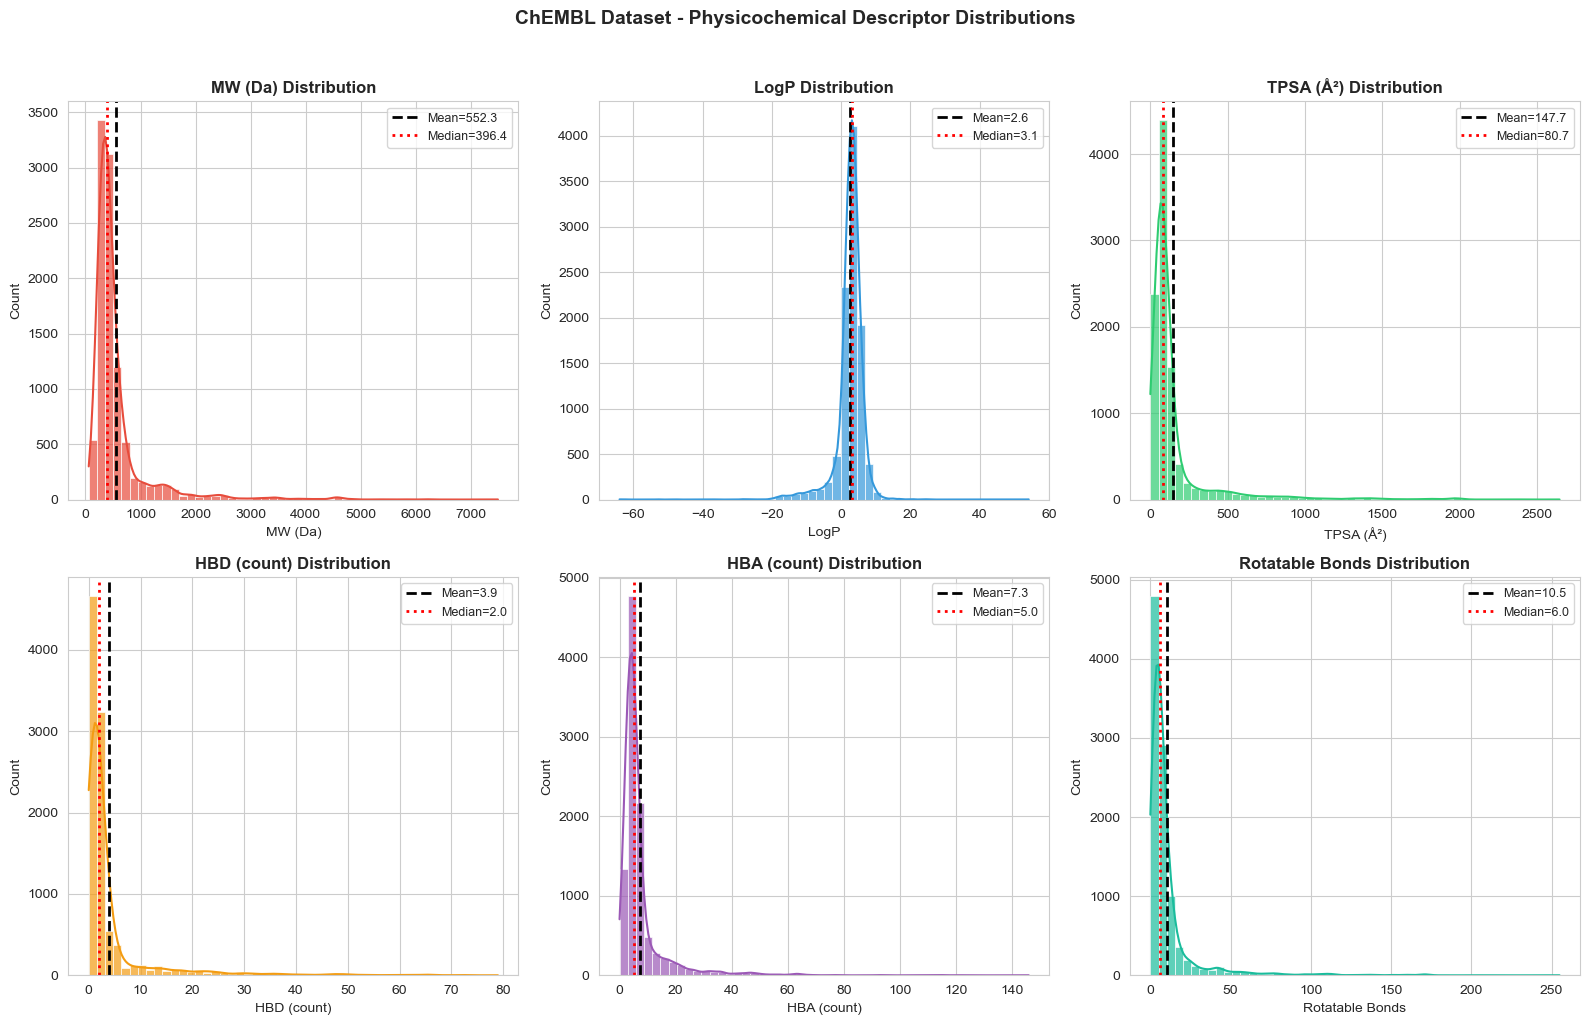

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

physico_desc = {
    'MW (Da)': df_final['MW'],
    'LogP': df_final['LogP'],
    'TPSA (Å²)': df_final['TPSA'],
    'HBD (count)': df_final['HBD'],
    'HBA (count)': df_final['HBA'],
    'Rotatable Bonds': df_final['RotatableBonds']
}

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for idx, (name, values) in enumerate(physico_desc.items()):
    ax = axes[idx // 3, idx % 3]

    # 直方图 + KDE
    sns.histplot(values, kde=True, ax=ax, color=colors[idx], bins=50, alpha=0.7)

    # 均值和中位数线
    mean_val = values.mean()
    median_val = values.median()
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=2, label=f'Mean={mean_val:.1f}')
    ax.axvline(median_val, color='red', linestyle=':', linewidth=2, label=f'Median={median_val:.1f}')

    ax.set_title(f'{name} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(name)
    ax.set_ylabel('Count')
    ax.legend(fontsize=9)

plt.suptitle('ChEMBL Dataset - Physicochemical Descriptor Distributions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('1_physicochemical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 结构性质

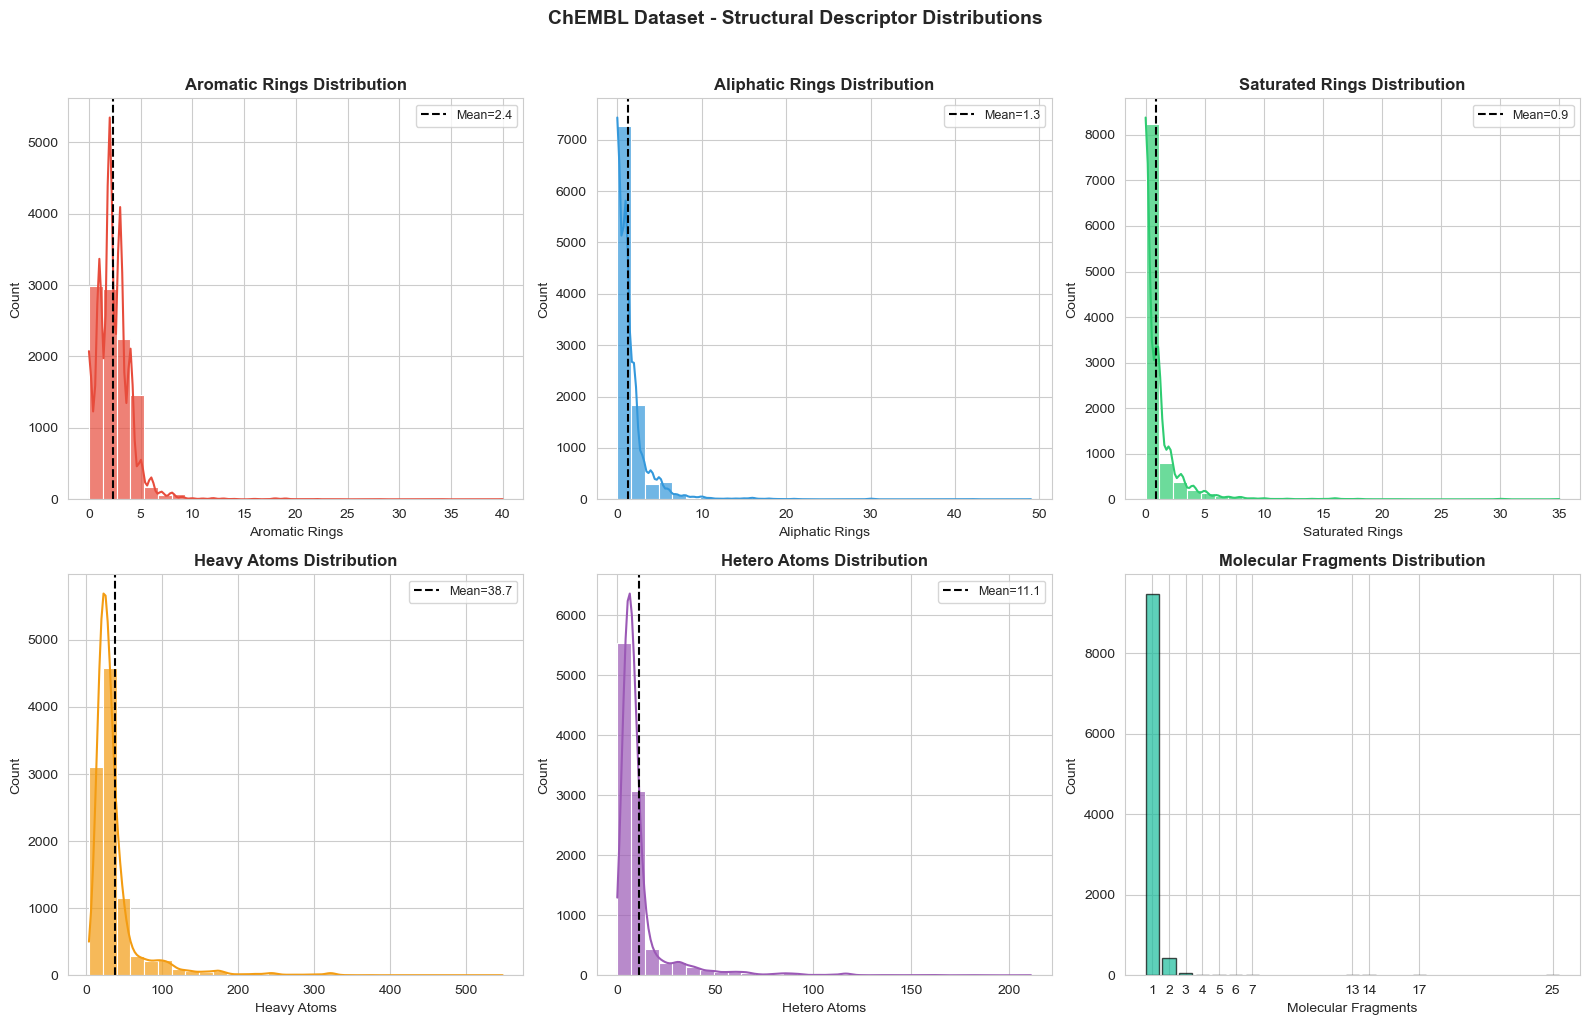

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

structural_desc = {
    'Aromatic Rings': df_final['AromaticRings'],
    'Aliphatic Rings': df_final['AliphaticRings'],
    'Saturated Rings': df_final['SaturatedRings'],
    'Heavy Atoms': df_final['HeavyAtoms'],
    'Hetero Atoms': df_final['HeteroAtoms'],
    'Molecular Fragments': df_final['SpiroAtoms']
}

for idx, (name, values) in enumerate(structural_desc.items()):
    ax = axes[idx // 3, idx % 3]

    # 对于离散值用bar，连续值用hist
    if values.nunique() <= 15:
        value_counts = values.value_counts().sort_index()
        ax.bar(value_counts.index, value_counts.values, color=colors[idx], alpha=0.7, edgecolor='black')
        ax.set_xticks(value_counts.index)
    else:
        sns.histplot(values, kde=True, ax=ax, color=colors[idx], bins=30, alpha=0.7)
        ax.axvline(values.mean(), color='black', linestyle='--', label=f'Mean={values.mean():.1f}')
        ax.legend(fontsize=9)

    ax.set_title(f'{name} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(name)
    ax.set_ylabel('Count')

plt.suptitle('ChEMBL Dataset - Structural Descriptor Distributions', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('2_structural_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Lipinski五规则筛选

In [8]:
def check_lipinski(row):

    rules = {
        'MW <= 500': row['MW'] <= 500,
        'LogP <= 5': row['LogP'] <= 5,
        'HBD <= 5': row['HBD'] <= 5,
        'HBA <= 10': row['HBA'] <= 10
    }

    violations = sum([not v for v in rules.values()])

    # 扩展规则：Veber规则（可旋转键 <= 10, TPSA <= 140）
    veber_rules = {
        'RotB <= 10': row['RotatableBonds'] <= 10,
        'TPSA <= 140': row['TPSA'] <= 140
    }

    return pd.Series({
        'lipinski_pass': violations <= 1,  # 最多1个违规
        'lipinski_violations': violations,
        'lipinski_strict_pass': violations == 0,  # 完全通过
        'veber_pass': all(veber_rules.values()),
        **{f'rule_{k}': v for k, v in rules.items()},
        **{f'veber_{k}': v for k, v in veber_rules.items()}
    })

# 应用筛选
print("正在应用Lipinski五规则...")
lipinski_results = df_final.apply(check_lipinski, axis=1)
df_final = pd.concat([df_final, lipinski_results], axis=1)

# 统计结果
pass_count = df_final['lipinski_pass'].sum()
strict_pass = df_final['lipinski_strict_pass'].sum()
veber_pass = df_final['veber_pass'].sum()
fail_count = len(df_final) - pass_count

print(f"\n 类药性筛选结果:")
print(f"=" * 50)
print(f"  Lipinski通过 (≤1违规):  {pass_count:>6} ({pass_count/len(df_final)*100:>5.1f}%)")
print(f"  Lipinski严格通过 (0违规): {strict_pass:>6} ({strict_pass/len(df_final)*100:>5.1f}%)")
print(f"  Veber规则通过:           {veber_pass:>6} ({veber_pass/len(df_final)*100:>5.1f}%)")
print(f"  失败 (>1违规):          {fail_count:>6} ({fail_count/len(df_final)*100:>5.1f}%)")
print(f"=" * 50)

print(f"\n违规数分布:")
print(df_final['lipinski_violations'].value_counts().sort_index())

正在应用Lipinski五规则...

 类药性筛选结果:
  Lipinski通过 (≤1违规):    7696 ( 77.0%)
  Lipinski严格通过 (0违规):   6084 ( 60.8%)
  Veber规则通过:             7173 ( 71.7%)
  失败 (>1违规):            2303 ( 23.0%)

违规数分布:
lipinski_violations
0    6084
1    1612
2    1095
3    1144
4      64
Name: count, dtype: int64


## Lipinski可视化 — 综合类药性分析

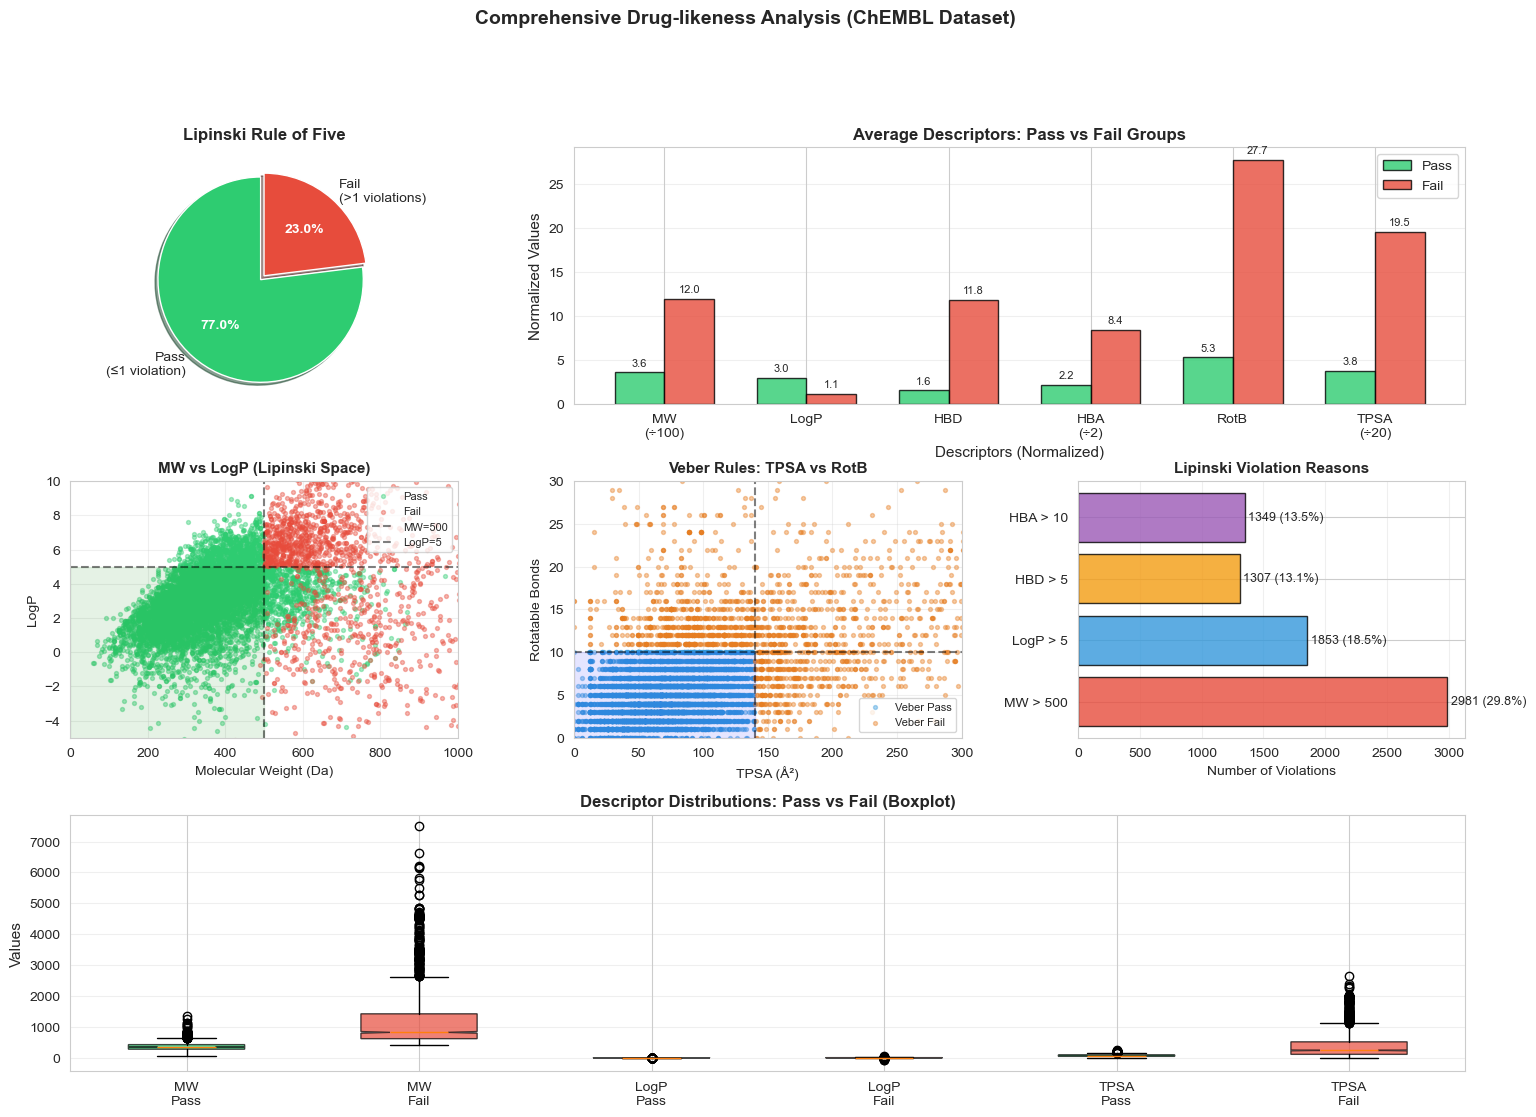

In [ ]:
fig = plt.figure(figsize=(18, 12))

# 创建网格布局
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. 饼图：Lipinski通过 vs 失败
ax1 = fig.add_subplot(gs[0, 0])
labels = ['Pass\n(≤1 violation)', 'Fail\n(>1 violations)']
sizes = [pass_count, fail_count]
colors_pie = ['#2ecc71', '#e74c3c']
explode = (0.05, 0)
wedges, texts, autotexts = ax1.pie(sizes, explode=explode, labels=labels, colors=colors_pie, 
                                    autopct='%1.1f%%', shadow=True, startangle=90,
                                    textprops={'fontsize': 10})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax1.set_title('Lipinski Rule of Five', fontsize=12, fontweight='bold')

# 2. 柱状图：通过/失败组的平均描述符对比
ax2 = fig.add_subplot(gs[0, 1:])
categories = ['MW\n(÷100)', 'LogP', 'HBD', 'HBA\n(÷2)', 'RotB', 'TPSA\n(÷20)']
pass_means = [
    df_final[df_final['lipinski_pass']]['MW'].mean() / 100,
    df_final[df_final['lipinski_pass']]['LogP'].mean(),
    df_final[df_final['lipinski_pass']]['HBD'].mean(),
    df_final[df_final['lipinski_pass']]['HBA'].mean() / 2,
    df_final[df_final['lipinski_pass']]['RotatableBonds'].mean(),
    df_final[df_final['lipinski_pass']]['TPSA'].mean() / 20
]
fail_means = [
    df_final[~df_final['lipinski_pass']]['MW'].mean() / 100,
    df_final[~df_final['lipinski_pass']]['LogP'].mean(),
    df_final[~df_final['lipinski_pass']]['HBD'].mean(),
    df_final[~df_final['lipinski_pass']]['HBA'].mean() / 2,
    df_final[~df_final['lipinski_pass']]['RotatableBonds'].mean(),
    df_final[~df_final['lipinski_pass']]['TPSA'].mean() / 20
]

x = np.arange(len(categories))
width = 0.35
bars1 = ax2.bar(x - width/2, pass_means, width, label='Pass', color='#2ecc71', alpha=0.8, edgecolor='black')
bars2 = ax2.bar(x + width/2, fail_means, width, label='Fail', color='#e74c3c', alpha=0.8, edgecolor='black')

ax2.set_xlabel('Descriptors (Normalized)', fontsize=11)
ax2.set_ylabel('Normalized Values', fontsize=11)
ax2.set_title('Average Descriptors: Pass vs Fail Groups', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories, fontsize=10)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# 在柱子上标注数值
for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

# 3. 散点图：MW vs LogP，按Lipinski着色
ax3 = fig.add_subplot(gs[1, 0])
pass_df = df_final[df_final['lipinski_pass']]
fail_df = df_final[~df_final['lipinski_pass']]

ax3.scatter(pass_df['MW'], pass_df['LogP'], c='#2ecc71', alpha=0.4, s=8, label='Pass')
ax3.scatter(fail_df['MW'], fail_df['LogP'], c='#e74c3c', alpha=0.4, s=8, label='Fail')

# 画Lipinski边界线
ax3.axvline(x=500, color='black', linestyle='--', alpha=0.5, label='MW=500')
ax3.axhline(y=5, color='black', linestyle='--', alpha=0.5, label='LogP=5')
ax3.fill_between([0, 500], [-10, -10], [5, 5], alpha=0.1, color='green')

ax3.set_xlabel('Molecular Weight (Da)', fontsize=10)
ax3.set_ylabel('LogP', fontsize=10)
ax3.set_title('MW vs LogP (Lipinski Space)', fontsize=11, fontweight='bold')
ax3.set_xlim(0, 1000)
ax3.set_ylim(-5, 10)
ax3.legend(fontsize=8, loc='upper right')
ax3.grid(alpha=0.3)

# 4. 散点图：TPSA vs Rotatable Bonds，按Veber着色
ax4 = fig.add_subplot(gs[1, 1])
veber_pass = df_final[df_final['veber_pass']]
veber_fail = df_final[~df_final['veber_pass']]

ax4.scatter(veber_pass['TPSA'], veber_pass['RotatableBonds'], c='#3498db', alpha=0.4, s=8, label='Veber Pass')
ax4.scatter(veber_fail['TPSA'], veber_fail['RotatableBonds'], c='#e67e22', alpha=0.4, s=8, label='Veber Fail')

ax4.axvline(x=140, color='black', linestyle='--', alpha=0.5)
ax4.axhline(y=10, color='black', linestyle='--', alpha=0.5)
ax4.fill_between([0, 140], [0, 0], [10, 10], alpha=0.1, color='blue')

ax4.set_xlabel('TPSA (Å²)', fontsize=10)
ax4.set_ylabel('Rotatable Bonds', fontsize=10)
ax4.set_title('Veber Rules: TPSA vs RotB', fontsize=11, fontweight='bold')
ax4.set_xlim(0, 300)
ax4.set_ylim(0, 30)
ax4.legend(fontsize=8)
ax4.grid(alpha=0.3)

# 5. 违规原因分析
ax5 = fig.add_subplot(gs[1, 2])
violation_reasons = {
    'MW > 500': (~df_final['rule_MW <= 500']).sum(),
    'LogP > 5': (~df_final['rule_LogP <= 5']).sum(),
    'HBD > 5': (~df_final['rule_HBD <= 5']).sum(),
    'HBA > 10': (~df_final['rule_HBA <= 10']).sum()
}
bars = ax5.barh(list(violation_reasons.keys()), list(violation_reasons.values()), 
                color=['#e74c3c', '#3498db', '#f39c12', '#9b59b6'], alpha=0.8, edgecolor='black')
ax5.set_xlabel('Number of Violations', fontsize=10)
ax5.set_title('Lipinski Violation Reasons', fontsize=11, fontweight='bold')
ax5.grid(axis='x', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, violation_reasons.values())):
    ax5.text(val + max(violation_reasons.values())*0.01, bar.get_y() + bar.get_height()/2, 
             f'{val} ({val/len(df_final)*100:.1f}%)', va='center', fontsize=9)

# 6. 描述符箱线图对比
ax6 = fig.add_subplot(gs[2, :])
box_data = [
    df_final[df_final['lipinski_pass']]['MW'].values,
    df_final[~df_final['lipinski_pass']]['MW'].values,
    df_final[df_final['lipinski_pass']]['LogP'].values,
    df_final[~df_final['lipinski_pass']]['LogP'].values,
    df_final[df_final['lipinski_pass']]['TPSA'].values,
    df_final[~df_final['lipinski_pass']]['TPSA'].values
]
box_labels = ['MW\nPass', 'MW\nFail', 'LogP\nPass', 'LogP\nFail', 'TPSA\nPass', 'TPSA\nFail']
box_colors = ['#2ecc71', '#e74c3c'] * 3

bp = ax6.boxplot(box_data, labels=box_labels, patch_artist=True, notch=True)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax6.set_ylabel('Values', fontsize=11)
ax6.set_title('Descriptor Distributions: Pass vs Fail (Boxplot)', fontsize=12, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

plt.suptitle('Comprehensive Drug-likeness Analysis (ChEMBL Dataset)', 
             fontsize=14, fontweight='bold', y=0.995)
# plt.savefig('3_lipinski_comprehensive.png', dpi=150, bbox_inches='tight')
plt.show()

## 描述符相关性热力图

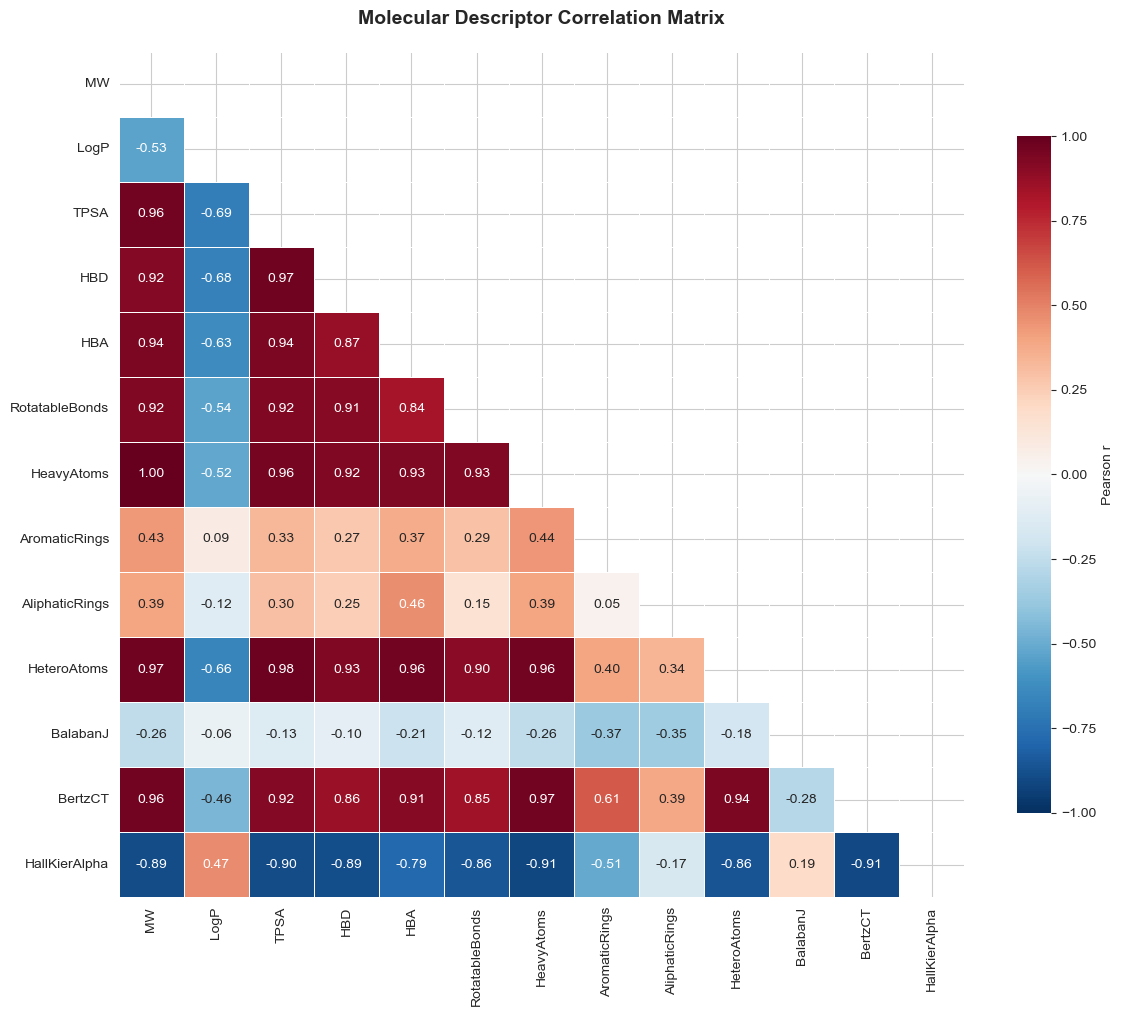


 关键相关性发现:
----------------------------------------
  MW ↔ HeavyAtoms: r = 0.998
  TPSA ↔ HeteroAtoms: r = 0.983
  TPSA ↔ HBD: r = 0.973
  MW ↔ HeteroAtoms: r = 0.971
  HeavyAtoms ↔ BertzCT: r = 0.966
  MW ↔ BertzCT: r = 0.965
  HBA ↔ HeteroAtoms: r = 0.964
  HeavyAtoms ↔ HeteroAtoms: r = 0.963
  MW ↔ TPSA: r = 0.962
  TPSA ↔ HeavyAtoms: r = 0.961


In [ ]:
# 选择核心描述符做相关性分析
core_desc = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 
             'HeavyAtoms', 'AromaticRings', 'AliphaticRings', 'HeteroAtoms',
             'BalabanJ', 'BertzCT', 'HallKierAlpha']

corr_matrix = df_final[core_desc].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8, "label": "Pearson r"},
            vmin=-1, vmax=1)

plt.title('Molecular Descriptor Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
# plt.savefig('4_descriptor_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# 打印关键相关性发现
print("\n 关键相关性发现:")
print("-" * 40)
# 找出强相关对（|r| > 0.7）
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.7:
            strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], r))

for desc1, desc2, r in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True)[:10]:
    print(f"  {desc1} ↔ {desc2}: r = {r:.3f}")

## 分子结构可视化 — 展示典型分子

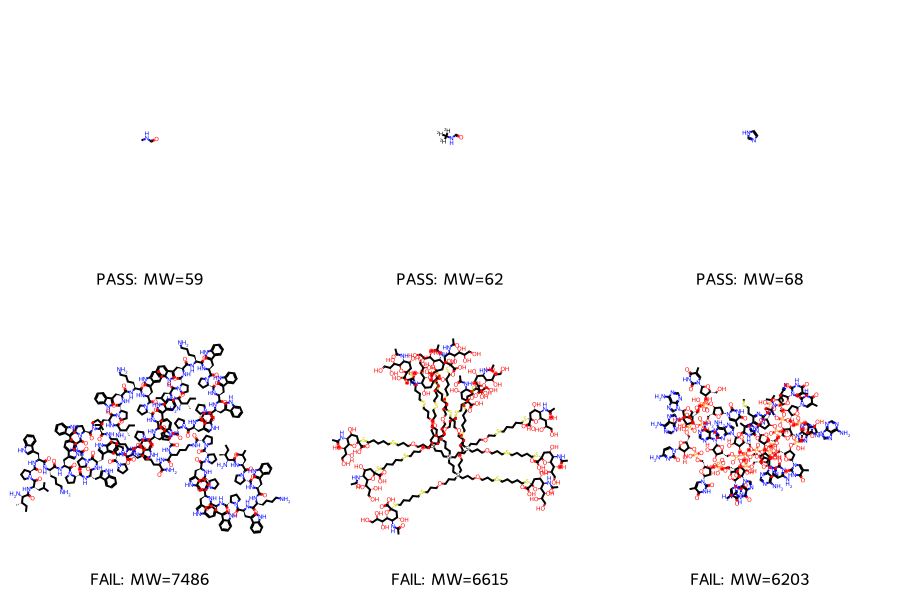

In [12]:
from rdkit.Chem import Draw

# 选取代表性分子
pass_small = df_final[df_final['lipinski_pass']].nsmallest(3, 'MW')
fail_large = df_final[~df_final['lipinski_pass']].nlargest(3, 'MW')

mols_to_draw = []
legends = []

for idx, row in pass_small.iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mols_to_draw.append(mol)
        legends.append(f"PASS: MW={row['MW']:.0f}")

for idx, row in fail_large.iterrows():
    mol = Chem.MolFromSmiles(row['canonical_smiles'])
    if mol:
        mols_to_draw.append(mol)
        legends.append(f"FAIL: MW={row['MW']:.0f}")


img = Draw.MolsToGridImage(
    mols_to_draw, 
    molsPerRow=3, 
    subImgSize=(300, 300),
    legends=legends
)
display(img)

## 描述符主成分分析

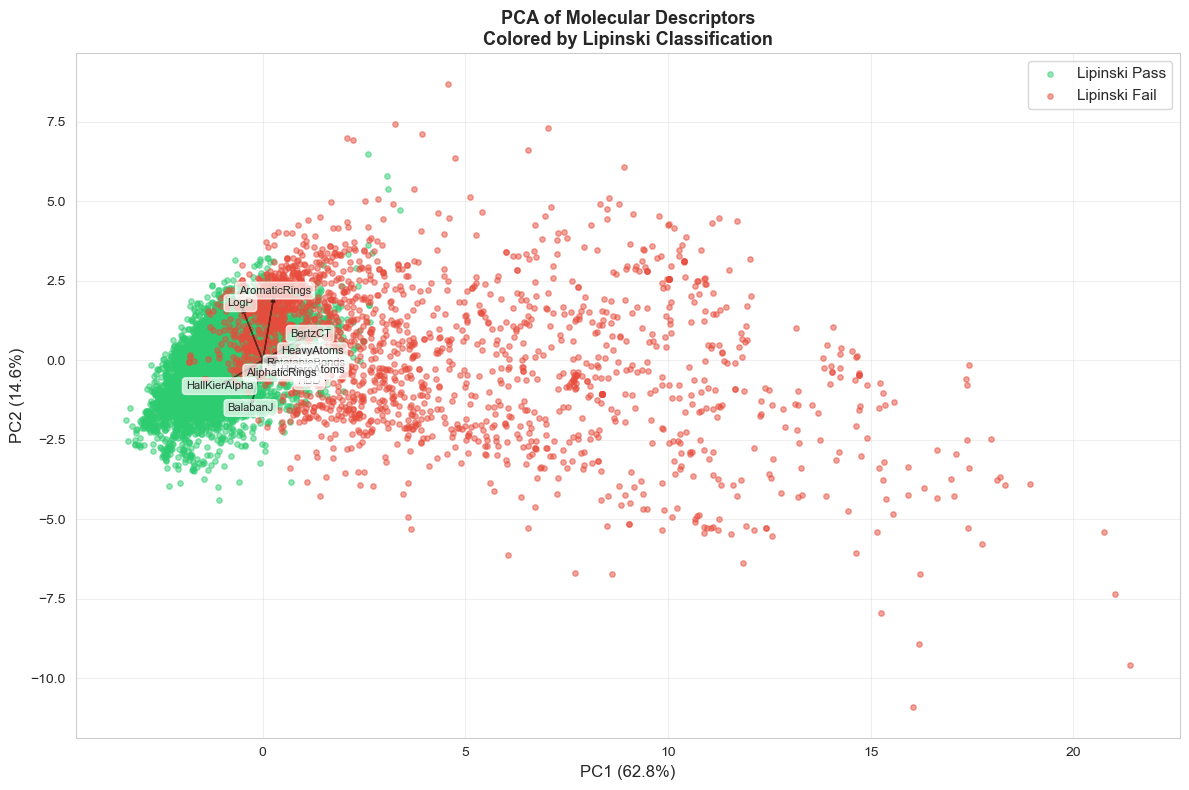


 PCA解释方差:
  PC1: 62.8%
  PC2: 14.6%
  累计: 77.4%

 PC1主要载荷:
  HeavyAtoms: 0.341
  MW: 0.340
  HeteroAtoms: 0.340
  TPSA: 0.338
  BertzCT: 0.324


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 选择数值型描述符（排除ID和SMILES）
feature_cols = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 
                'HeavyAtoms', 'HeteroAtoms', 'AromaticRings', 'AliphaticRings',
                'BalabanJ', 'BertzCT', 'HallKierAlpha']

# 去除缺失值和异常值
df_pca = df_final[feature_cols].dropna()
df_pca = df_pca[(df_pca['BalabanJ'] < 100) & (df_pca['BertzCT'] < 5000)]  # 去除极端异常值

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 绘图
plt.figure(figsize=(12, 8))

# 按Lipinski着色
pass_mask = df_final.loc[df_pca.index, 'lipinski_pass'].values
scatter = plt.scatter(X_pca[pass_mask, 0], X_pca[pass_mask, 1], 
                      c='#2ecc71', alpha=0.5, s=15, label='Lipinski Pass')
plt.scatter(X_pca[~pass_mask, 0], X_pca[~pass_mask, 1], 
            c='#e74c3c', alpha=0.5, s=15, label='Lipinski Fail')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
plt.title('PCA of Molecular Descriptors\nColored by Lipinski Classification', 
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# 添加特征向量
feature_vectors = pca.components_.T * 3  # 缩放以便可视化
for i, col in enumerate(feature_cols):
    plt.arrow(0, 0, feature_vectors[i, 0], feature_vectors[i, 1], 
              color='black', alpha=0.5, head_width=0.1)
    plt.text(feature_vectors[i, 0]*1.2, feature_vectors[i, 1]*1.2, col, 
             fontsize=8, ha='center', va='center', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.tight_layout()
# plt.savefig('6_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n PCA解释方差:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  累计: {sum(pca.explained_variance_ratio_)*100:.1f}%")

print(f"\n PC1主要载荷:")
pc1_loadings = pd.Series(pca.components_[0], index=feature_cols).sort_values(key=abs, ascending=False)
for desc, loading in pc1_loadings.head(5).items():
    print(f"  {desc}: {loading:.3f}")